**1- Import needed libraries**

In [2]:
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import random # Generate pseudo-random numbers
from random import randint

from sklearn.utils import shuffle # Shuffle arrays or sparse matrices in a consistent way
from sklearn.model_selection import train_test_split # Split arrays or matrices into random train and test subsets
from sklearn.metrics import classification_report, confusion_matrix
import sklearn

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # Specifies the geometry of the grid that a subplot can be placed in.

import keras
from keras import models as Models
from keras import layers as Layers
from keras.preprocessing import image
from keras.models import Sequential,Model
from keras.layers import Input,InputLayer, Dense, Activation, ZeroPadding2D, BatchNormalization
from keras.layers import Flatten, Conv2D, AveragePooling2D, MaxPooling2D, Dropout
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint,EarlyStopping
from keras import utils as Utils
from keras.utils import to_categorical # Converts a class vector (integers) to binary class matrix.

from keras.utils.vis_utils import model_to_dot

import seaborn as sns

# from IPython.display import SVG

import arabic_reshaper # Reconstruct Arabic sentences to be used in applications that don't support Arabic
from bidi.algorithm import get_display

Using TensorFlow backend.


In [4]:
# global variables
Language = "Ar"
ImageClassMapping_path = "../input/Labels/ImagesClassPath.csv"
ClassLabels_path = "../input/Labels/ClassLabels.xlsx"
ImagesRoot_path = "../input/"

ModelFileName ='Model_255.h5'

**2- Load Data**


In [5]:
# load 54k image path mapping
df_ImageClassPath = pd.read_csv(ImageClassMapping_path)
display(df_ImageClassPath.head())

,id,ClassId,ImagePath
0,1,0,ArASL_Database_54K/ain/AIN (1).JPG
1,2,0,ArASL_Database_54K/ain/AIN (10).JPG
2,3,0,ArASL_Database_54K/ain/AIN (100).jpg
3,4,0,ArASL_Database_54K/ain/AIN (1000).JPG
4,5,0,ArASL_Database_54K/ain/AIN (1001).JPG


In [6]:
# load Class Labels
df_Classes = pd.read_excel(ClassLabels_path)
display(df_Classes.head())

,ClassId,Class,ClassAr
0,0,ain,عين
1,1,al,ال
2,2,aleff,الف
3,3,bb,باء
4,4,dal,دال


In [7]:
df_ImageClassPath.groupby("ClassId").size().describe()

count      32.000000
mean     1689.031250
std       187.343825
min      1293.000000
25%      1589.500000
50%      1713.500000
75%      1797.250000
max      2114.000000
dtype: float64

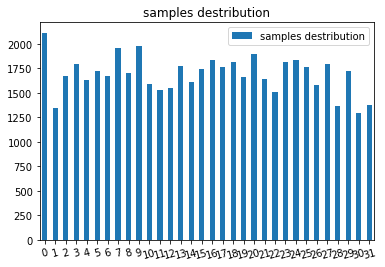

In [8]:

ddata = {"samples destribution":df_ImageClassPath.groupby("ClassId").size()}
iindex = range(32)

ddataframe = pd.DataFrame(data=ddata, index= iindex)
ddataframe.plot.bar(stacked= True, rot= 15, title='samples destribution')
plt.show(block= True)

In [9]:
# Split 54K Images into 3 groups of Fixed Prediction, training and test
# the dataset is 32 class,split is maintaind as per class 
def SplitData(predictions,testsize):
    
    min = df_ImageClassPath.groupby("ClassId").size().min()
    print('{0} Samples per Class'.format(min))
    
    # empty dataframes with same column difinition
    df_TrainingSet = df_ImageClassPath[0:0].copy()
    df_TestSet = df_ImageClassPath[0:0].copy()
    df_PredSet = df_ImageClassPath[0:0].copy()

    # Create the sets by loop thru classes and append
    for index,row in df_Classes.iterrows():
        # make sure all class are same size 
        df_FullSet = df_ImageClassPath[df_ImageClassPath['ClassId'] == row['ClassId']].sample(min,random_state= 42)
        
#         df_FullSet = df_ImageClassPath[df_ImageClassPath['ClassId'] == row['ClassId']]
        
        df_PredSet = df_PredSet.append(df_FullSet.sample(n=predictions, random_state=1))
        df_FullSet = pd.merge(df_FullSet,df_PredSet, indicator=True, 
                              how='left').query('_merge=="left_only"').drop('_merge', axis=1)
        
        trainingSet, testSet = train_test_split(df_FullSet, test_size= testsize)        
        
        df_TrainingSet = df_TrainingSet.append(trainingSet)
        df_TestSet = df_TestSet.append(testSet)
    
    return df_TrainingSet,df_TestSet,df_PredSet


In [10]:
# retrive class Label (Arabic or English) using class id 
def get_classlabel(class_code,lang= 'Ar'):
    if lang== 'Ar':
        text_to_be_reshaped = df_Classes.loc[df_Classes['ClassId'] == class_code, 
                                             'ClassAr'].values[0]
        reshaped_text = arabic_reshaper.reshape(text_to_be_reshaped)
        return get_display(reshaped_text)
    elif lang== 'En':
        return df_Classes.loc[df_Classes['ClassId'] == class_code, 'Class'].values[0]
    

In [11]:
# prepare Images, and class Arrays
def getDataSet(setType,isDL): # 'Training' for Training dataset , 'Testing' for Testing data set
    imgs = []
    lbls = []
    df = pd.DataFrame(None)
    
    if setType =='Training':
        df = dtTraining.copy()
    elif setType=='Test':
        df = dtTest.copy()
    elif setType=='Prediction':
        df = dtPred.copy()

    for index,row in df.iterrows():
        lbls.append(row['ClassId'])
        try:
            imageFilePath = os.path.join(ImagesRoot_path, row['ImagePath'])
            img = image.load_img(imageFilePath, target_size=(64,64,1), 
                                 color_mode = "grayscale")
            img = image.img_to_array(img) # to array
            img = img/255 # Normalize
            if isDL == False:
                img = img.flatten() # for knn_classifier Model
            imgs.append(img)

        except Exception as e:
            print(e)
            
    shuffle(imgs,lbls,random_state=255) #Shuffle the dataset

    imgs = np.array(imgs)
    lbls = np.array(lbls)
    if isDL ==True:
        lbls = to_categorical(lbls) # for keras CNN Model
    return imgs, lbls

In [12]:
def display_prediction(col_size, row_size,XPred,yPred): 
    img_index=0
    fig, ax = plt.subplots(row_size, col_size, figsize=(row_size*2.5,col_size*1.5))
    for row in range(0,row_size):
        for col in range(0,col_size):
            ax[row][col].imshow(XPred[img_index][:,:,0], cmap='gray')
            ax[row][col].set_title("({}) {}".format(yPred[img_index],get_classlabel(yPred[img_index],'Ar')))
            ax[row][col].set_xticks([])
            ax[row][col].set_yticks([])
            img_index += 1

**4- Preparing Data**

In [13]:
# Split our Dataset into Training, Test and Prediction
# take 3 images per class for later prediction (96 images 3 x 32 class category)
# split the remaining into 20% test and 80% Training

dtTraining, dtTest,dtPred = SplitData(3,0.3)

1293 Samples per Class


In [14]:
print('Pred     {} \t # {} per class'.format(dtPred.shape[0], dtPred.shape[0] //32))
print('Training {} \t # {} per class'.format(dtTraining.shape[0], dtTraining.shape[0] //32))
print('Test     {} \t # {} per class'.format(dtTest.shape[0], dtTest.shape[0] //32))
print('---------------')
print('Sum      {}'.format(dtTraining.shape[0] + dtTest.shape[0] + dtPred.shape[0]))

Pred     96 	 # 3 per class
Training 28896 	 # 903 per class
Test     12384 	 # 387 per class
---------------
Sum      41376


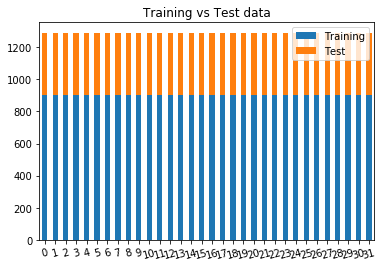

In [15]:
ddata = {"Training":dtTraining.groupby("ClassId").size(),"Test":dtTest.groupby("ClassId").size()}
iindex = range(32)

ddataframe = pd.DataFrame(data=ddata, index= iindex)
ddataframe.plot.bar(stacked= True, rot= 15, title='Training vs Test data')
plt.show(block= True)

**5- Model Definition**

In [22]:
X_train,y_train = getDataSet('Training',True)
X_valid,y_valid = getDataSet('Test',True)
X_pred,_ = getDataSet('Prediction',True)

In [23]:
print("Shape of Train Images:{} , Train Labels: {}".format(X_train.shape,y_train.shape))
print("Shape of Test Images:{} , Test Labels: {}".format(X_valid.shape,y_valid.shape))
print("Shape of Prediction Images:{} , Prediction Labels: {}".format(X_pred.shape,"?"))

Shape of Train Images:(28896, 64, 64, 1) , Train Labels: (28896, 32)
Shape of Test Images:(12384, 64, 64, 1) , Test Labels: (12384, 32)
Shape of Prediction Images:(96, 64, 64, 1) , Prediction Labels: ?


Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 62, 62, 64)        640       
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 60, 60, 64)        36928     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 30, 30, 64)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 30, 30, 64)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 57600)             0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               7372928   
_________________________________________________________________
dropout_2 (Dropout)          (None, 128)              

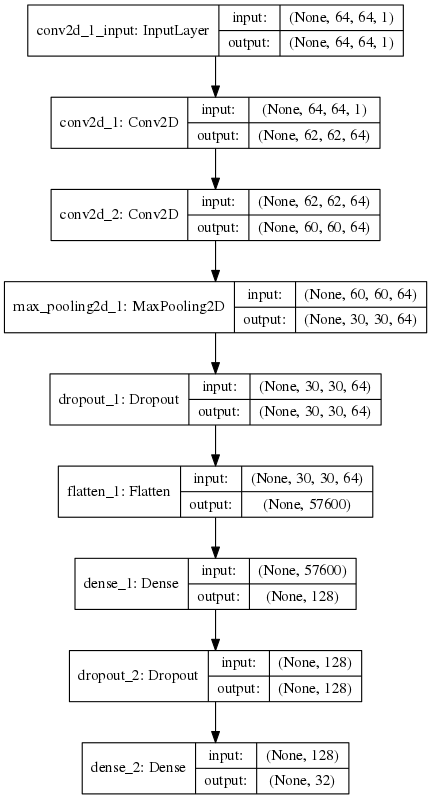

In [24]:
model = Models.Sequential()

model.add(Layers.Conv2D(64, kernel_size=(3, 3),activation='relu',input_shape=(64,64,1)))
model.add(Layers.Conv2D(64, (3, 3), activation='relu'))
model.add(Layers.MaxPooling2D(pool_size=(2, 2)))
model.add(Layers.Dropout(0.25))
model.add(Layers.Flatten())
model.add(Layers.Dense(128, activation='relu'))
model.add(Layers.Dropout(0.5))
model.add(Layers.Dense(32, activation='softmax'))

model.compile(loss='categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

model.summary()
Utils.plot_model(model,to_file='model.png',show_shapes=True, show_layer_names=True, dpi=80)


**6- Model Training**

In [28]:
callbacks_list =[EarlyStopping(monitor='val_loss', patience=10), ModelCheckpoint(
    filepath='model_255.h5', monitor='val_loss', save_best_only= True),]

trained = model.fit(X_train, y_train, epochs=35, validation_data=(X_valid, y_valid), 
                    callbacks= callbacks_list)


Train on 28896 samples, validate on 12384 samples
Epoch 1/35
28896/28896 [==============================] - 16s 541us/step - loss: 1.9048 - accuracy: 0.4564 - val_loss: 0.5664 - val_accuracy: 0.8585
Epoch 2/35
28896/28896 [==============================] - 12s 417us/step - loss: 0.7399 - accuracy: 0.7773 - val_loss: 0.3372 - val_accuracy: 0.9134
Epoch 3/35
28896/28896 [==============================] - 12s 417us/step - loss: 0.5083 - accuracy: 0.8423 - val_loss: 0.2814 - val_accuracy: 0.9269
Epoch 4/35
28896/28896 [==============================] - 12s 416us/step - loss: 0.4298 - accuracy: 0.8687 - val_loss: 0.2767 - val_accuracy: 0.9306
Epoch 5/35
28896/28896 [==============================] - 12s 413us/step - loss: 0.3399 - accuracy: 0.8933 - val_loss: 0.2401 - val_accuracy: 0.9375
Epoch 6/35
28896/28896 [==============================] - 12s 412us/step - loss: 0.2674 - accuracy: 0.9132 - val_loss: 0.2255 - val_accuracy: 0.9432
Epoch 7/35
28896/28896 [==============================] 

* <a href="./model_255.h5"> Download Model File </a>

**7- Model Evaluation**

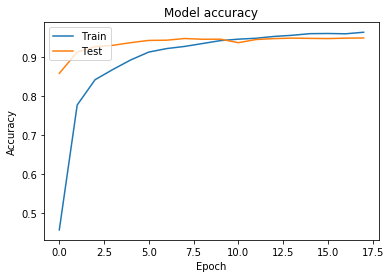

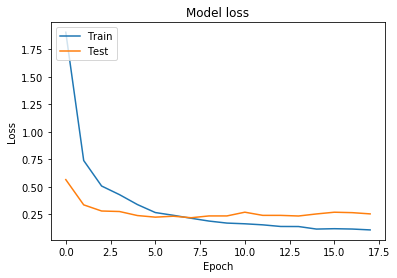

In [29]:
plt.plot(trained.history['accuracy'])
plt.plot(trained.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

plt.plot(trained.history['loss'])
plt.plot(trained.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [30]:
print("on Validation data")
pred1=model.evaluate(X_valid,y_valid)
print("accuaracy", str(pred1[1]*100))
print("Total loss",str(pred1[0]*100))

on Validation data
12384/12384 [==============================] - 2s 126us/step
accuaracy 94.94509100914001
Total loss 25.517088645224938


**8- Reports**

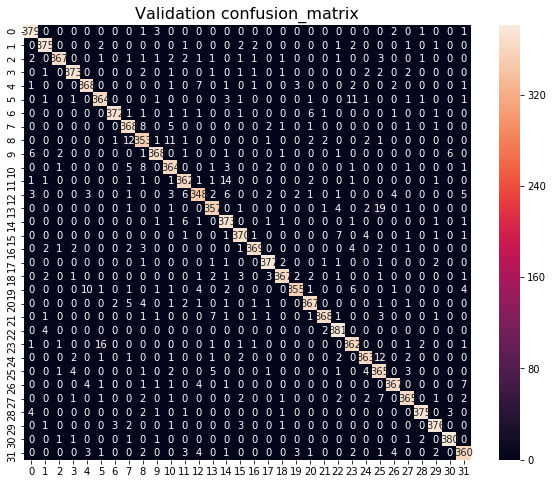

In [31]:
from sklearn.metrics import confusion_matrix
Y_prediction = model.predict(X_valid)
# Convert predictions classes to one hot vectors 
Y_pred_classes = np.argmax(Y_prediction,axis = 1) 
# Convert validation observations to one hot vectors
Y_true = np.argmax(y_valid,axis = 1) 
# compute the confusion matrix
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes) 

plt.figure(figsize=(10,8))
plt.title('Validation confusion_matrix', fontsize = 16) 
sns.heatmap(confusion_mtx, annot=True, fmt="d");


**9- Model Prediction**

In [32]:
cnn_Y_pred = model.predict(X_pred)
cnn_Y_pred = np.argmax(cnn_Y_pred,axis = 1)
print(cnn_Y_pred)

[ 0  0  0  1  1  1  2  2  2  3  3  3  4  4  4  5  5  5  6  6  6  7  7  7
  8  8  8  9  9  9 10 10 10 11 11 11 12 12 11 13 13 13 11 14 14 15 15 15
 16 16 16 17 17 17 18 18 18 23 19 19 20 20 20 21 21 21 22 22  1 23 23 23
 24 24 24 25 25 25 26 26 26 27  3 27 28 28 28 21 29 29 30 30 30 31 31 31]


In [33]:
def display_prediction(col_size, row_size,XPred,yPred): 
    img_index=0
    fig, ax = plt.subplots(row_size, col_size, figsize=(row_size*2.5,col_size*1.5))
    for row in range(0,row_size):
        for col in range(0,col_size):
            ax[row][col].imshow(X_pred[img_index][:,:,0], cmap='gray')
            ax[row][col].set_title("({}) {}".format(yPred[img_index],get_classlabel(yPred[img_index],'Ar')))
            ax[row][col].set_xticks([])
            ax[row][col].set_yticks([])
            img_index += 1

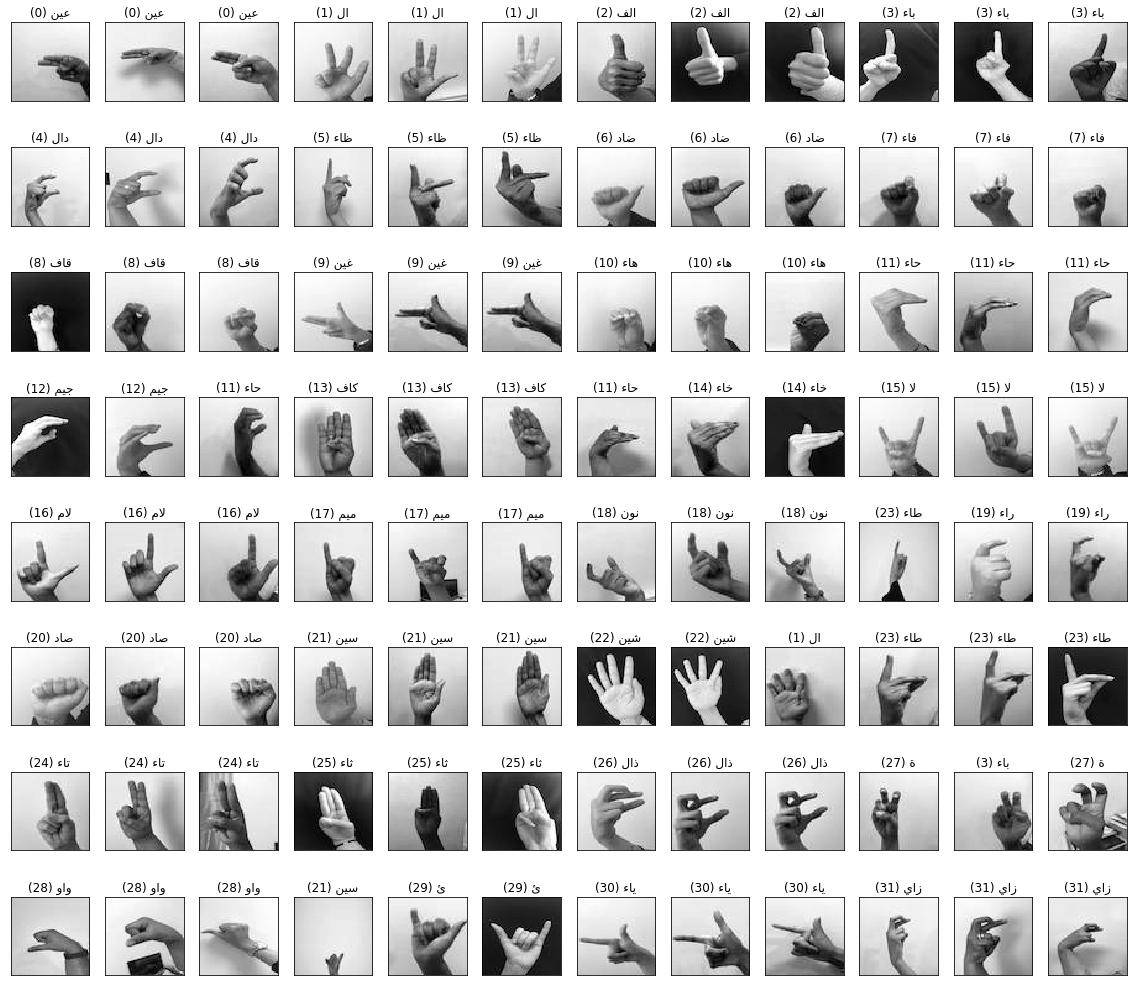

In [34]:
display_prediction(12,8,X_pred,cnn_Y_pred)